In [2]:
# uv check script
# executable should be in /.venv/bin/python
import os
import sys
print(f"cwd: {os.getcwd()}")
print(f"executable: {sys.executable}")

try:
    import pandas
    print("pandas is present")
except ImportError:
    print("pandas not found")

cwd: /workspace/AML-3-MVL-AI-Classifier/notebooks
executable: /workspace/AML-3-MVL-AI-Classifier/.venv/bin/python
pandas is present


# Preprocessing Script

## Imports

In [ ]:
import pandas as pd
import os
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
#import torch
import numpy as np
#import torchvision.models as models
#import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns

# RAPIDS GPU acceleration
#import cuml
#from cuml.manifold import TSNE


## Data Loading

The following cells will load the data, exclude duplicates and low quality images and then randomly sample the dataset to have it balanced between both categories and models.

In [4]:
df = pd.read_parquet('image_metadata.parquet')
print(f"base: {len(df)} images")
df = df[~df['filename'].str.startswith(('[DUPE]', '[LQ]'))]
print(f"filtered: {len(df)} images")

base: 2341506 images
filtered: 2223389 images


In [5]:
TARGET_SIZE = 140000
SEED = 42

df = df.groupby(['category', 'model_type']).sample(n=TARGET_SIZE, random_state=SEED)
print(df.groupby(['category', 'model_type']).size())
len(df)


category  model_type           
ai        ADM                      140000
          Glide                    140000
          Midjourney               140000
          Stable Diffusion v1.4    140000
          Stable Diffusion v1.5    140000
          VQDM                     140000
          Wukong                   140000
nature    ADM                      140000
          Glide                    140000
          Midjourney               140000
          Stable Diffusion v1.4    140000
          Stable Diffusion v1.5    140000
          VQDM                     140000
          Wukong                   140000
dtype: int64


1960000

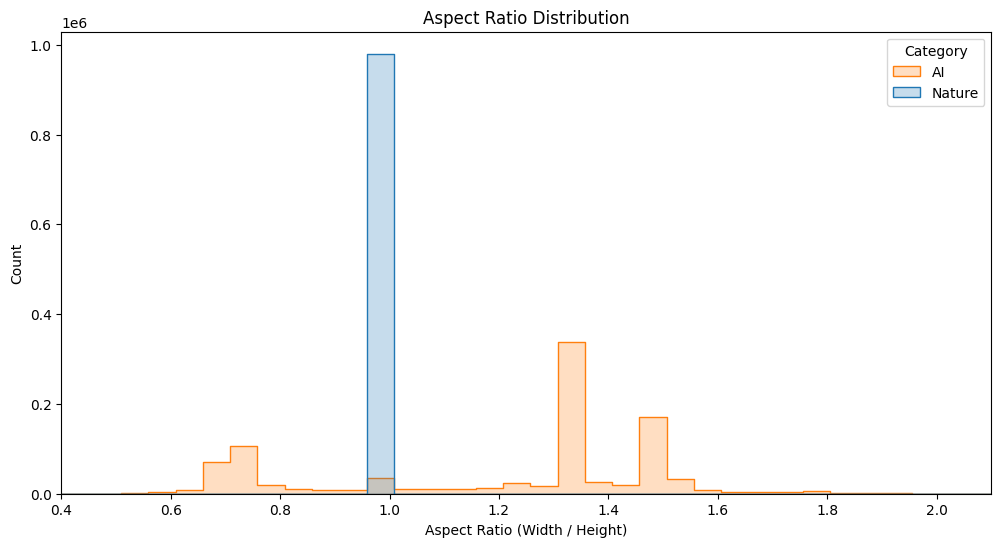

In [6]:
plt.figure(figsize=(12, 6))

# 1. We use a smaller binwidth for more detail
# 2. we set common aspect ratio boundaries
sns.histplot(
    data=df, 
    x='aspect_ratio', 
    hue='category', 
    element="step",       # 'step' makes overlapping distributions easier to see
    binwidth=0.05,       # smaller bins for better precision
    common_norm=False    # helps compare shapes if one category has way more images
)

# Focus the view on where 99% of images live
plt.xlim(0.4, 2.1) 

# Add vertical lines for common ratios to make it "readable" at a glance
#plt.axvline(1.0, color='gray', linestyle='--', alpha=0.6, label='Square (1:1)')
#plt.axvline(1.33, color='gray', linestyle=':', alpha=0.6, label='Standard (4:3)')
#plt.axvline(1.77, color='gray', linestyle='-.', alpha=0.6, label='Widescreen (16:9)')

plt.title('Aspect Ratio Distribution')
plt.xlabel('Aspect Ratio (Width / Height)')
plt.legend(title='Category', labels=['AI', 'Nature'])

plt.show()

In [14]:
print(df['category'].value_counts())

category
ai        980000
nature    980000
Name: count, dtype: int64


To run the following we need different dependencies not used in the project, these are taken out since a older version of nummpy is required than what we use in the project.

    "cuml-cu12>=25.6.0",
    "ipywidgets>=8.1.8",
    "numpy<2.2",
    "pandas>=2.1.1",
    "scikit-learn>=1.5,<1.6",
    "torch>=2.11.0",
    "torchaudio>=2.11.0",
    "torchvision>=0.26.0",
    "tqdm>=4.67.3",
    "pyarrow>=15.0.0,<17.0.0",

In [1]:
# Aggregate counts so we can map count to dot size
res_summary = df.groupby(['width', 'height', 'category']).size().reset_index(name='count')


plt.figure(figsize=(12, 8))

# Use the same plotting code as before
sns.scatterplot(
    data=res_summary.sort_values('count'),
    x="width", 
    y="height", 
    hue="category",
    size="count",
    sizes=(10, 500),
    alpha=0.6,
    palette={'ai': '#1f77b4', 'nature': '#ff7f0e'}
)

# --- ZOOMING LOGIC ---
plt.xlim(0, 5000)  # Ignore the 9000px outlier
plt.ylim(0, 5000)  # Ignore the 6500px outlier
# ---------------------
plt.ylabel('Height in pixels')
plt.xlabel('Width in pixels')
plt.title("Resolution Distribution")
plt.show()

NameError: name 'df' is not defined

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch CUDA Version: {torch.version.cuda}")
print(f"GPU Device: {torch.cuda.get_device_name(0)}")

PyTorch CUDA Version: 13.0
GPU Device: NVIDIA GeForce RTX 3060


In [9]:
# %% [markdown]
# # GPU Accelerated Image t-SNE
# This notebook handles feature extraction and dimensionality reduction on the GPU.

# %%
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.models as models
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# RAPIDS GPU acceleration
from cuml.manifold import TSNE

# %% [markdown]
# ### 1. Hardware & Model Setup
# We use ResNet50 as a feature extractor.

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device} ({torch.cuda.get_device_name(0)})")

# 1. Define Model: Load ResNet50 and strip the last layer (fc)
# This converts images into 2048-dimensional feature vectors
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = nn.Sequential(*(list(resnet.children())[:-1]))
model.to(device)
model.eval()

# 2. Define Preprocess: Must match ImageNet standards
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# %% [markdown]
# ### 2. Data Loading Architecture
# Optimized for Unraid disk speeds using multiprocessing.

# %%
class RobustImageDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
        
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        try:
            with Image.open(self.paths[idx]) as img:
                return self.transform(img.convert('RGB')), True
        except Exception:
            # Return a blank tensor if the file is corrupted
            return torch.zeros(3, 224, 224), False

# %% [markdown]
# ### 3. Extraction Loop
# We sample 30,000 images for a clear visualization.

# %%
# Sample 30k images from your balanced_df
sample_df = df.sample(30000, random_state=42).reset_index(drop=True)

dataset = RobustImageDataset(sample_df['path'].tolist(), preprocess)
# num_workers=4 helps pull data from Unraid disks in parallel
loader = DataLoader(dataset, batch_size=128, num_workers=4, pin_memory=True)

embeddings = []

with torch.no_grad():
    for imgs, success_mask in tqdm(loader, desc="Extracting Features"):
        imgs = imgs.to(device, non_blocking=True)
        
        # Extract features (shape will be [batch, 2048, 1, 1])
        output = model(imgs)
        
        # Flatten and move to CPU
        embeddings.append(output.squeeze().cpu().numpy())

# Combine into one large matrix
features_matrix = np.vstack(embeddings)
print(f"Features extracted. Matrix shape: {features_matrix.shape}")

# %% [markdown]
# ### 4. GPU t-SNE (cuML)
# This runs the heavy math on your RTX 3060.

# %%
print("Starting GPU t-SNE...")
tsne = TSNE(
    n_components=2, 
    perplexity=100, 
    n_neighbors=100, 
    random_state=42
)

# Perform the dimensionality reduction
projections = tsne.fit_transform(features_matrix)

# Map back to our dataframe
sample_df['tsne_x'] = projections[:, 0]
sample_df['tsne_y'] = projections[:, 1]

# %% [markdown]
# ### 5. Final Plotting

# %%


Using device: cuda (NVIDIA GeForce RTX 3060)


Extracting Features: 100%|██████████| 235/235 [00:52<00:00,  4.44it/s]


Features extracted. Matrix shape: (30000, 2048)
Starting GPU t-SNE...
[2026-05-01 13:53:38.491] [CUML] [warning] Perplexity should be within ranges (5, 50). Your results might be a bit strange...
[2026-05-01 13:53:38.491] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...


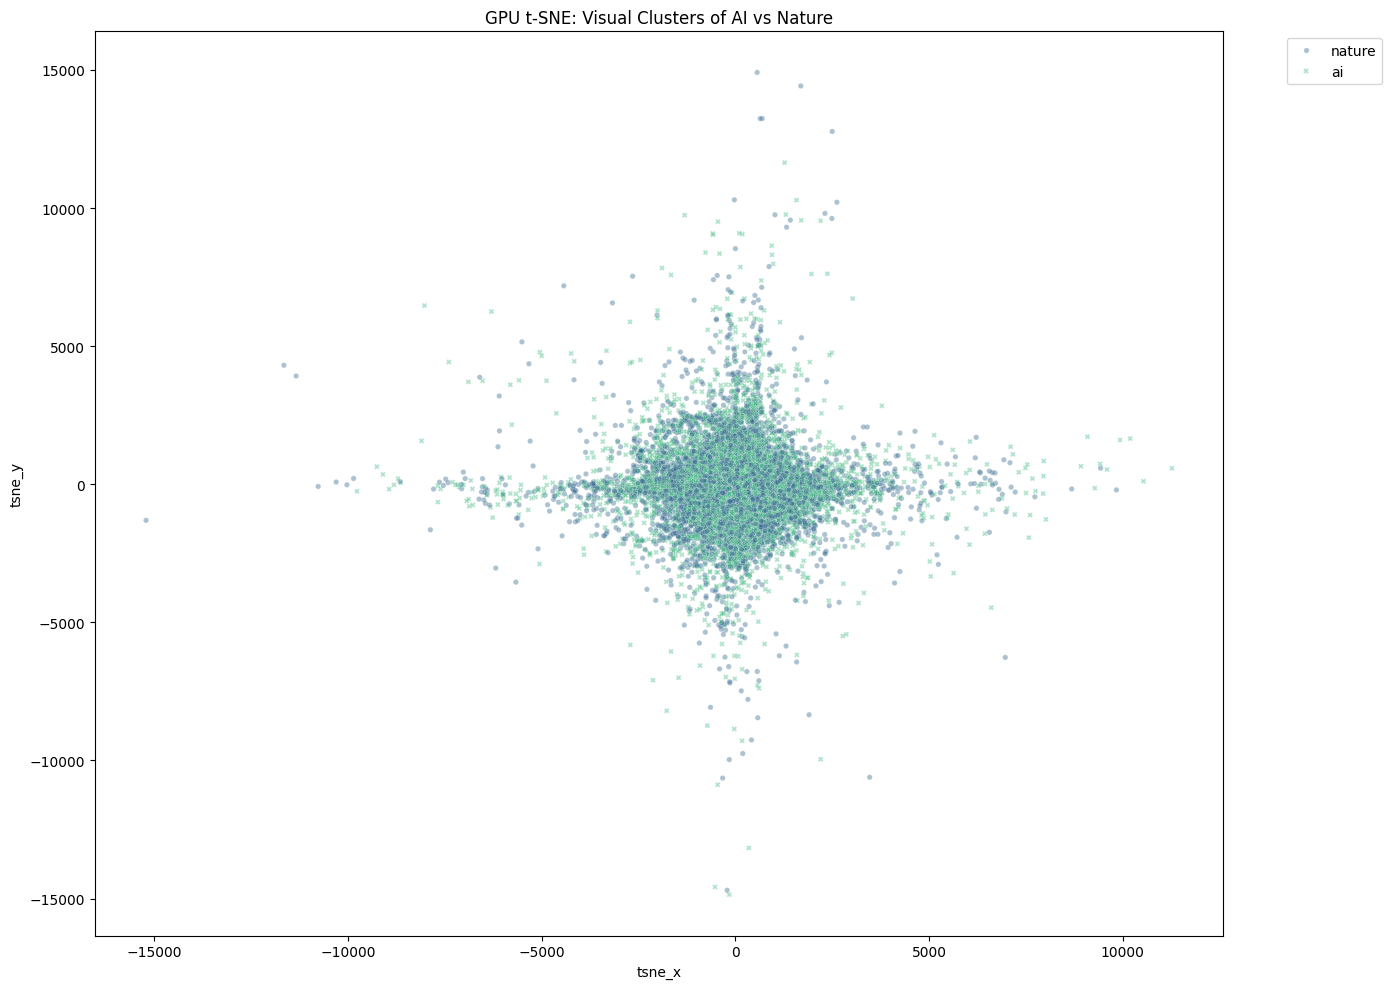

In [10]:
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=sample_df,
    x='tsne_x', y='tsne_y',
    hue='category',
    style='category',
    alpha=0.4,
    s=15,
    palette='viridis'
)
 
plt.title('GPU t-SNE: Visual Clusters of AI vs Nature')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

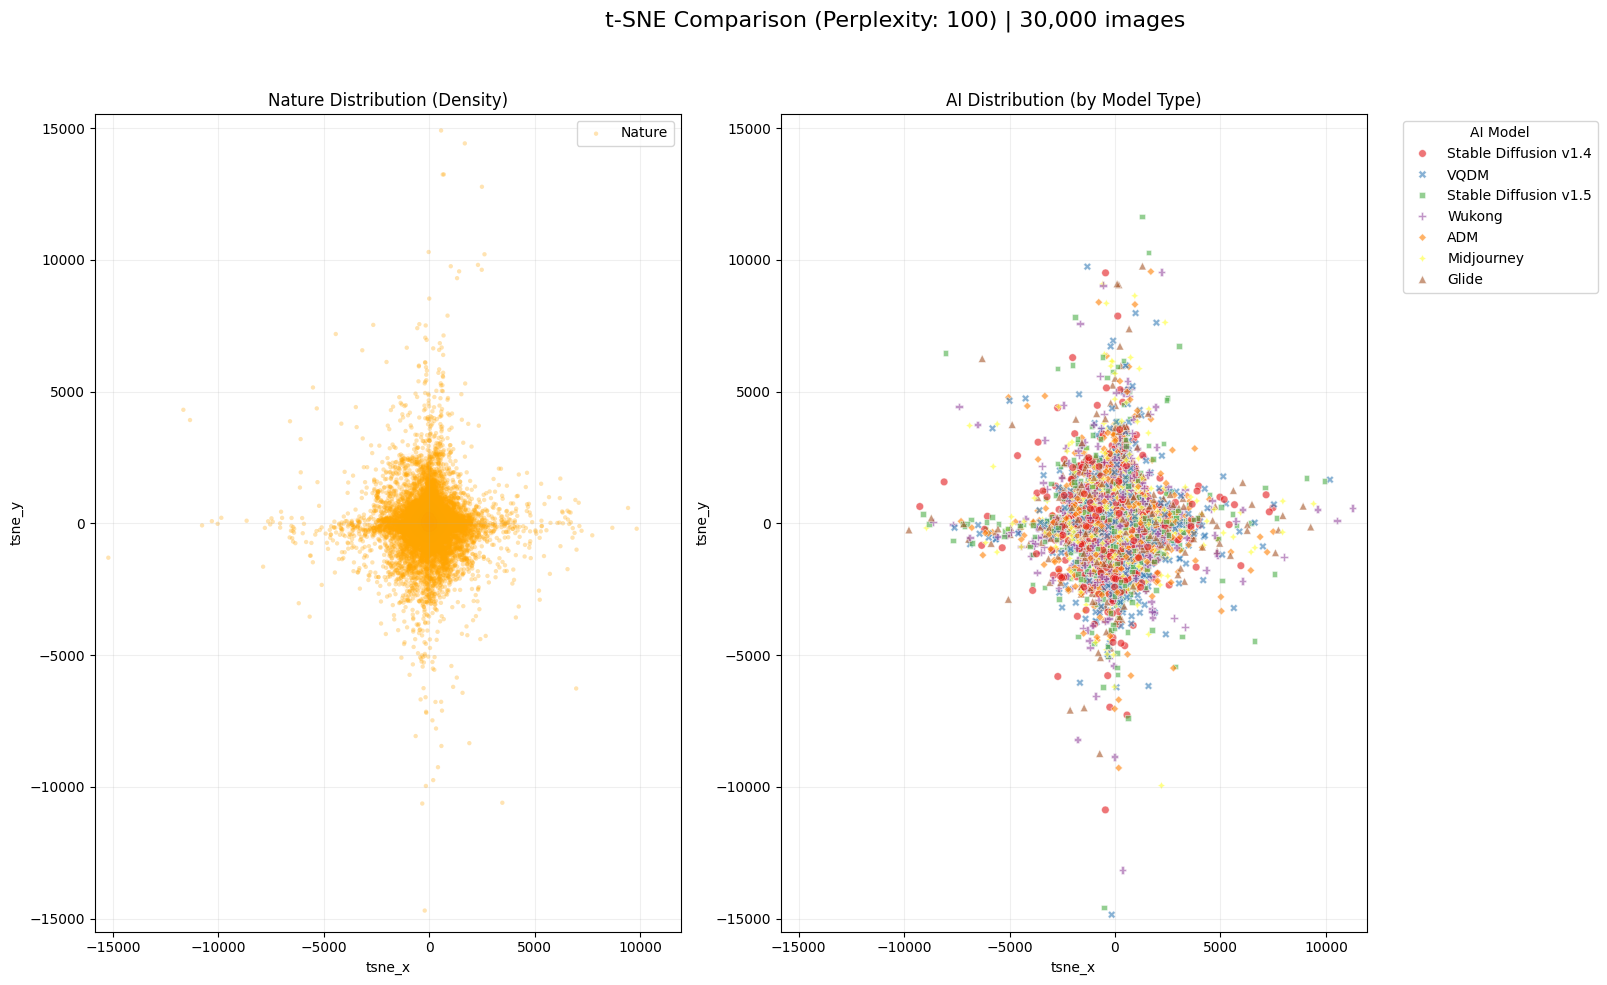

In [11]:
# %% [markdown]
# ### 5. Enhanced Visualization: Shapes, Stylyes, and Density
# We break the comparison down by model type and use a density map to fight overplotting.

# %%
import matplotlib.patches as mpatches

plt.figure(figsize=(18, 10))

# 1. Create side-by-side subplots for visual separation
ax1 = plt.subplot(1, 2, 1)
ax2 = plt.subplot(1, 2, 2, sharex=ax1, sharey=ax1) # Share axes for true comparison

# --- Plot 1: NATURE DENSITY ---
df_nature = sample_df[sample_df['category'] == 'nature']
sns.kdeplot(
    data=df_nature, x='tsne_x', y='tsne_y', 
    fill=True, thresh=0.05, levels=10, cmap="Oranges", alpha=0.5, ax=ax1
)
sns.scatterplot(
    data=df_nature, x='tsne_x', y='tsne_y', 
    color="orange", alpha=0.3, s=10, edgecolor='none', ax=ax1, label='Nature'
)
ax1.set_title('Nature Distribution (Density)')


# --- Plot 2: AI MODEL STRUCTURE (Shapes!) ---
df_ai = sample_df[sample_df['category'] == 'ai']
# Map the density underlay first
sns.kdeplot(
    data=df_ai, x='tsne_x', y='tsne_y', 
    fill=True, thresh=0.05, levels=10, cmap="Blues", alpha=0.5, ax=ax2
)

# NOW MAP SHAPES TO MODELS
# Make sure your 'model_type' column is clean (using NAME_MAP)
sns.scatterplot(
    data=df_ai, 
    x='tsne_x', y='tsne_y', 
    hue='model_type',     # Unique colors per model
    style='model_type',   # Unique shapes per model!
    palette='Set1',       # High-contrast color palette
    alpha=0.6, s=30, edgecolor='w', linewidth=0.5,
    ax=ax2
)
ax2.set_title('AI Distribution (by Model Type)')

# Final formatting
plt.suptitle(f't-SNE Comparison (Perplexity: 100) | {len(sample_df):,} images', fontsize=16)
ax1.grid(True, alpha=0.2)
ax2.grid(True, alpha=0.2)
# Move the complex legend out of the way
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='AI Model')

plt.tight_layout(rect=[0, 0, 0.9, 0.95])
plt.show()